# Data preparation v3 — features and phase offsets in one notebook

This notebook replaces both the v2 data preparation (Part A of the combined notebook) and `06_phase_offsets`. Its output contains **everything Test 4 needs in one place**, so the Test 4 notebook only needs this one input.

**What it produces:**

| File | Contents |
|---|---|
| `X_train_v2.npy`, `X_kaggle_test_v2.npy` | 12 features per chunk for the labelled and Kaggle test signals (same as v2) |
| `meta_train_v2.csv`, `meta_kaggle_test.csv` | Signal metadata, with the same train/validation/test split as before |
| `feature_names.json` | The 12 feature names |
| `phase_offsets_train.csv`, `phase_offsets_kaggle_test.csv` | Where each recording starts in the voltage cycle, and the shift needed to align it |
| `test3_summary.csv` | Copied from the combined notebook if attached, so Test 4 can compare with Test 3 |

**Two ways it can run:**
- **Fast (about 20–30 minutes):** if the combined notebook's committed output is attached, its saved features are reused and copied, and only the phase offsets are calculated.
- **Full (about 1–2 hours):** if not, the features and offsets are calculated together in one pass over the raw data.

**Inputs:** the competition data (always needed, since the offsets come from the raw signals), plus optionally the combined notebook's output. No GPU is needed. Run once with `LIMIT = 60` as a quick test, then set `LIMIT = None` and commit with **Save & Run All**.

## 1. Settings

In [1]:
import glob, json, shutil
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pywt
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

OUT_DIR = '/kaggle/working'
LIMIT = None                 # quick test; set to None for all signals
FORCE_PREP = False         # True = recalculate the features even if saved ones are attached

N_SAMPLES = 800_000
FS = N_SAMPLES / 0.02              # 40 MHz
HIGHPASS_CUTOFF = 10_000           # Hz
N_CHUNKS = 160
CHUNK_LEN = N_SAMPLES // N_CHUNKS  # 5,000 samples
DEG_PER_CHUNK = 360 / N_CHUNKS     # 2.25 degrees
SPLIT_SEED = 42
PEAK_LOW, PEAK_HIGH, MIN_PEAK_DISTANCE = 5, 8, 20
FEATURE_NAMES = ['mean', 'std', 'min', 'max', 'range', 'p1', 'p99',
                 'pulses_5sd', 'pulses_8sd', 'pos_pulses_5sd', 'neg_pulses_5sd', 'pulse_strength_sum']
N_FEATURES = len(FEATURE_NAMES)

## 2. Find the inputs and decide what to calculate

The raw competition data is always required. If full-size saved features (all 8,712 signals) are attached, and this isn't a quick test, they are reused; quick-test feature files are ignored automatically.

In [2]:
raw_meta = glob.glob('/kaggle/input/**/metadata_train.csv', recursive=True)
assert raw_meta, 'Competition data not found: Add Input > Competition Datasets > vsb-power-line-fault-detection'
DATA_DIR = raw_meta[0].rsplit('/', 1)[0]

saved = glob.glob('/kaggle/input/**/X_train_v2.npy', recursive=True)
saved_full = bool(saved) and np.load(saved[0], mmap_mode='r').shape[0] == 8712
REUSE_FEATURES = saved_full and not FORCE_PREP and LIMIT is None
if REUSE_FEATURES:
    SAVED_DIR = saved[0].rsplit('/', 1)[0]
    print('Reusing saved features from', SAVED_DIR, '- only phase offsets will be calculated (fast mode)')
else:
    if saved and not saved_full:
        print('Attached feature files are from a quick test, so they are ignored.')
    print('Features and phase offsets will both be calculated from the raw data in', DATA_DIR)

Features and phase offsets will both be calculated from the raw data in /kaggle/input/competitions/vsb-power-line-fault-detection


## 3. Functions

**Features** (unchanged from v2): high-pass filter (5th-order zero-phase Butterworth, 10 kHz), level-1 `db4` wavelet denoising, 7 basic features and 5 pulse features per chunk.

**Phase offset** (from `06_phase_offsets`): the recording is approximately `A·cos(2πn/N + φ)`. One Fourier coefficient gives φ, and from it the shift that moves the positive-going zero crossing (0° of the voltage cycle) to the start. The shift is also stored in chunks (rounded, so the alignment error is at most ±1.1°).

In [3]:
SOS = signal.butter(5, HIGHPASS_CUTOFF, btype='highpass', fs=FS, output='sos')
n = np.arange(N_SAMPLES)
COS = np.cos(2 * np.pi * n / N_SAMPLES).astype(np.float32)
SIN = np.sin(2 * np.pi * n / N_SAMPLES).astype(np.float32)

def highpass(x):
    return signal.sosfiltfilt(SOS, x)

def wavelet_denoise(x, wavelet='db4', level=1):
    coeffs = pywt.wavedec(x, wavelet, mode='per', level=level)
    sigma = np.median(np.abs(coeffs[-1] - np.median(coeffs[-1]))) / 0.6745
    coeffs[1:] = [pywt.threshold(c, value=sigma * np.sqrt(2 * np.log(len(x))), mode='hard') for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet, mode='per')[:len(x)]

def basic_features(x):
    chunks = x.reshape(N_CHUNKS, -1)
    return np.stack([chunks.mean(1), chunks.std(1), chunks.min(1), chunks.max(1), chunks.max(1) - chunks.min(1),
                     np.percentile(chunks, 1, axis=1), np.percentile(chunks, 99, axis=1)], axis=1)

def find_pulses(x):
    sigma = np.median(np.abs(x - np.median(x))) / 0.6745 + 1e-9
    z = x / sigma
    peaks, props = signal.find_peaks(np.abs(z), height=PEAK_LOW, distance=MIN_PEAK_DISTANCE)
    return peaks, props['peak_heights'], np.sign(z[peaks]), sigma

def pulse_features(x):
    peaks, heights, signs, _ = find_pulses(x)
    chunk = peaks // CHUNK_LEN
    count = lambda mask: np.bincount(chunk[mask], minlength=N_CHUNKS)
    return np.stack([count(np.ones(len(peaks), bool)), count(heights >= PEAK_HIGH), count(signs > 0),
                     count(signs < 0), np.bincount(chunk, weights=heights, minlength=N_CHUNKS)], axis=1)

def features(raw):
    x = wavelet_denoise(highpass(raw.astype(np.float32)))
    return np.concatenate([basic_features(x), pulse_features(x)], axis=1).astype(np.float32)

def phase_offset(raw):
    x = raw.astype(np.float32)
    a, b = float(x @ COS), float(x @ SIN)
    phi = np.arctan2(-b, a)
    shift = int(round(((-(phi + np.pi / 2)) % (2 * np.pi)) / (2 * np.pi) * N_SAMPLES)) % N_SAMPLES
    return phi, 2 * np.hypot(a, b) / N_SAMPLES, shift

## 4. Labels and split

The split code and seed are identical to v1 and v2, so every signal stays in the same set (training 6,096, validation 1,308, test 1,308). When saved features are reused, a check confirms their split matches.

In [4]:
meta = pd.read_csv(f'{DATA_DIR}/metadata_train.csv')
meta_k = pd.read_csv(f'{DATA_DIR}/metadata_test.csv')
meas = meta.groupby('id_measurement')['target'].max().reset_index()
train_ids, temp_ids = train_test_split(meas['id_measurement'], test_size=0.30, stratify=meas['target'], random_state=SPLIT_SEED)
temp = meas[meas['id_measurement'].isin(temp_ids)]
val_ids, test_ids = train_test_split(temp['id_measurement'], test_size=0.50, stratify=temp['target'], random_state=SPLIT_SEED)
split_map = {**{m: 'train' for m in train_ids}, **{m: 'val' for m in val_ids}, **{m: 'test' for m in test_ids}}
meta['split'] = meta['id_measurement'].map(split_map)
assert meta['split'].notna().all()
if REUSE_FEATURES:
    saved_meta = pd.read_csv(f'{SAVED_DIR}/meta_train_v2.csv')
    assert (saved_meta['signal_id'].values == meta['signal_id'].values).all() and (saved_meta['split'].values == meta['split'].values).all(), \
        'saved features use a different split or order'
print(meta.groupby('split')['target'].agg(count='count', pd_share='mean'))

       count  pd_share
split                 
test    1308  0.055810
train   6096  0.061188
val     1308  0.060398


## 5. Visual checks

**Left/right:** four signals before and after alignment; after alignment, all should start at zero and rise.
**Bottom:** strong pulses (≥8σ) of the first PD signal, by voltage phase angle after alignment.

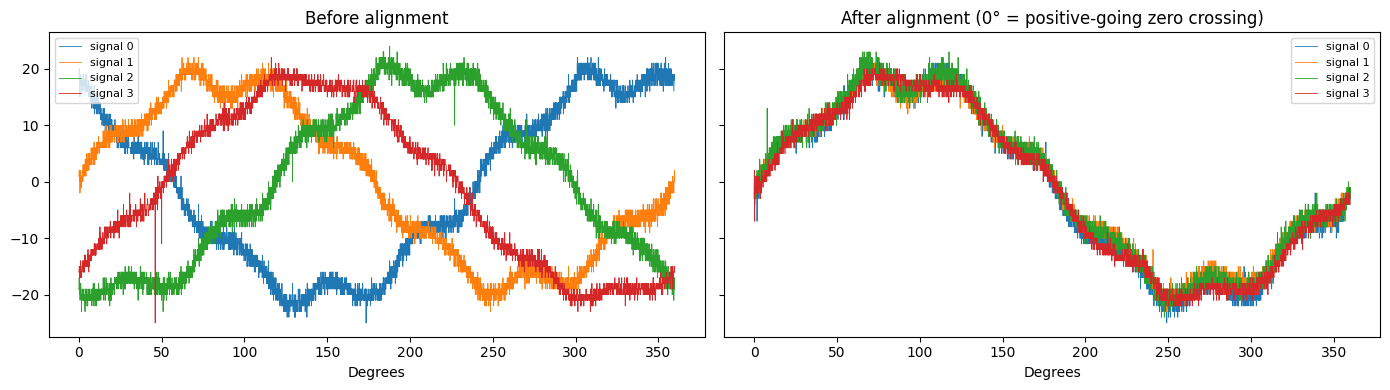

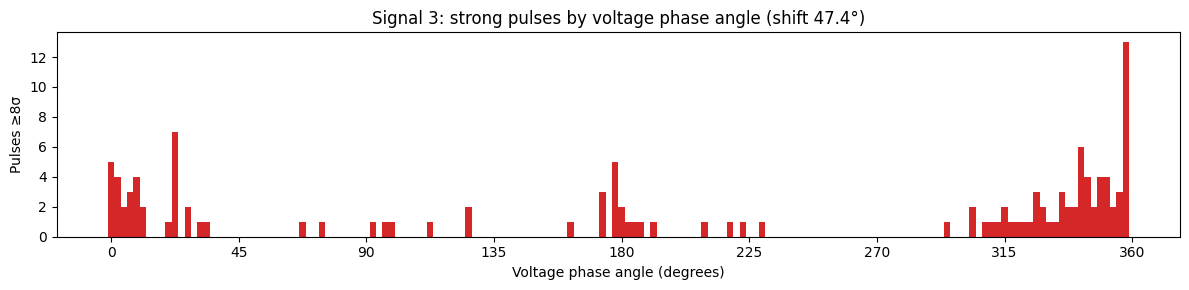

In [5]:
ids = meta['signal_id'].values[:4]
table = pq.read_table(f'{DATA_DIR}/train.parquet', columns=[str(s) for s in ids])
deg = np.arange(0, N_SAMPLES, 200) / N_SAMPLES * 360
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for s in ids:
    raw = table.column(str(s)).to_numpy()
    shift = phase_offset(raw)[2]
    axes[0].plot(deg, raw[::200], linewidth=0.6, label=f'signal {s}')
    axes[1].plot(deg, np.roll(raw, -shift)[::200], linewidth=0.6, label=f'signal {s}')
axes[0].set_title('Before alignment'); axes[1].set_title('After alignment (0° = positive-going zero crossing)')
for ax in axes:
    ax.set_xlabel('Degrees'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

sid = meta.loc[meta['target'] == 1, 'signal_id'].iloc[0]
raw = pq.read_table(f'{DATA_DIR}/train.parquet', columns=[str(sid)]).column(0).to_numpy()
shift = phase_offset(raw)[2]
strong = features(raw)[:, FEATURE_NAMES.index('pulses_8sd')]
aligned = np.roll(strong, -int(round(shift / CHUNK_LEN)))
plt.figure(figsize=(12, 3))
plt.bar(np.arange(N_CHUNKS) * DEG_PER_CHUNK, aligned, width=DEG_PER_CHUNK, color='tab:red')
plt.xticks(range(0, 361, 45)); plt.xlabel('Voltage phase angle (degrees)'); plt.ylabel('Pulses ≥8σ')
plt.title(f'Signal {sid}: strong pulses by voltage phase angle (shift {(shift * 360 / N_SAMPLES) % 360:.1f}°)')
plt.tight_layout(); plt.show()

## 6. Process the signals and save everything

Each raw signal is read once (300 at a time). Its phase offset is always calculated; its features are calculated only in full mode. In fast mode, the saved feature files are copied into this notebook's output, so Test 4 finds everything in one place.

In [6]:
def run(parquet_file, ids, with_features):
    X = np.zeros((len(ids), N_CHUNKS, N_FEATURES), dtype=np.float32) if with_features else None
    rows = []
    for start in tqdm(range(0, len(ids), 300), desc=parquet_file):
        batch = ids[start:start + 300]
        table = pq.read_table(f'{DATA_DIR}/{parquet_file}', columns=[str(s) for s in batch])
        for j, s in enumerate(batch):
            raw = table.column(str(s)).to_numpy()
            phi, amp, shift = phase_offset(raw)
            rows.append((s, phi, amp, shift, int(round(shift / CHUNK_LEN)) % N_CHUNKS))
            if with_features:
                X[start + j] = features(raw)
        del table
    return X, pd.DataFrame(rows, columns=['signal_id', 'phi_rad', 'amplitude', 'shift_samples', 'shift_chunks'])

run_meta = meta.iloc[:LIMIT] if LIMIT else meta
run_k = meta_k.iloc[:LIMIT] if LIMIT else meta_k
X_train, off_train = run('train.parquet', run_meta['signal_id'].values, not REUSE_FEATURES)
X_k, off_k = run('test.parquet', run_k['signal_id'].values, not REUSE_FEATURES)

if REUSE_FEATURES:
    for f in ['X_train_v2.npy', 'X_kaggle_test_v2.npy', 'feature_names.json']:
        shutil.copy(f'{SAVED_DIR}/{f}', f'{OUT_DIR}/{f}')
    X_train = np.load(f'{OUT_DIR}/X_train_v2.npy')
else:
    np.save(f'{OUT_DIR}/X_train_v2.npy', X_train); np.save(f'{OUT_DIR}/X_kaggle_test_v2.npy', X_k)
    with open(f'{OUT_DIR}/feature_names.json', 'w') as f:
        json.dump(FEATURE_NAMES, f)
run_meta.to_csv(f'{OUT_DIR}/meta_train_v2.csv', index=False)
run_k.to_csv(f'{OUT_DIR}/meta_kaggle_test.csv', index=False)
off_train.to_csv(f'{OUT_DIR}/phase_offsets_train.csv', index=False)
off_k.to_csv(f'{OUT_DIR}/phase_offsets_kaggle_test.csv', index=False)

t3 = glob.glob('/kaggle/input/**/test3_summary.csv', recursive=True)
if t3:
    shutil.copy(t3[0], f'{OUT_DIR}/test3_summary.csv'); print('Copied test3_summary.csv for the Test 4 comparison')
print('Saved: features', X_train.shape, '| offsets', len(off_train), 'labelled,', len(off_k), 'Kaggle test')

train.parquet:   0%|          | 0/30 [00:00<?, ?it/s]

test.parquet:   0%|          | 0/68 [00:00<?, ?it/s]

Saved: features (8712, 160, 12) | offsets 8712 labelled, 20337 Kaggle test


## 7. Checks

- **Start positions:** a spread across 0–360° confirms alignment is needed.
- **Weak 50 Hz waves:** signals with a 50 Hz amplitude under 10% of the median, whose phase estimate may be unreliable.
- **Pulse features:** PD signals should average clearly more pulses than normal signals.

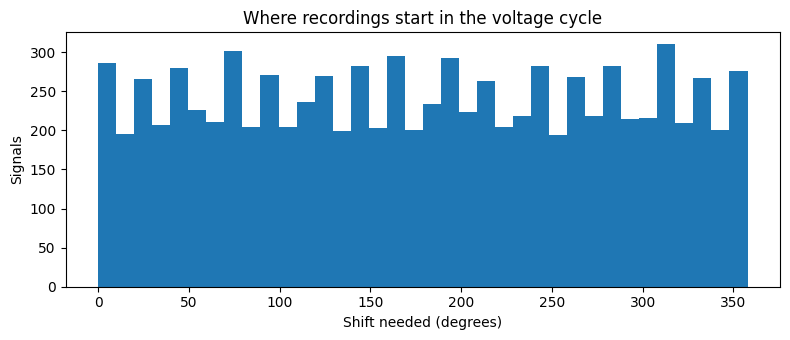

Median 50 Hz amplitude: 20.4 | weak 50 Hz waves: 58 of 29049
PD     signals: average  545.2 pulses ≥8σ
Normal signals: average  111.7 pulses ≥8σ


In [7]:
plt.figure(figsize=(8, 3.5))
plt.hist(off_train['shift_chunks'] * DEG_PER_CHUNK, bins=36, color='tab:blue')
plt.xlabel('Shift needed (degrees)'); plt.ylabel('Signals'); plt.title('Where recordings start in the voltage cycle')
plt.tight_layout(); plt.show()

amp = pd.concat([off_train['amplitude'], off_k['amplitude']])
print(f'Median 50 Hz amplitude: {amp.median():.1f} | weak 50 Hz waves: {(amp < 0.1 * amp.median()).sum()} of {len(amp)}')

y_run = run_meta['target'].values
total = X_train[:, :, FEATURE_NAMES.index('pulses_8sd')].sum(axis=1)
for label, name in [(1, 'PD'), (0, 'Normal')]:
    print(f'{name:6s} signals: average {total[y_run == label].mean():6.1f} pulses ≥8σ')

## Next step

After the quick test, set `LIMIT = None` and commit with **Save & Run All**, naming the version something like `v3 - features + phase offsets`. Then attach this notebook's output to the Test 4 notebook as its only input.